In [9]:
import torch 
import numpy as np 
import matplotlib.pyplot as plt
from itertools import islice
import json

from cryo_sbi.wpa_simulator.cryo_em_simulator import cryo_em_simulator
from cryo_sbi import CryoEmSimulator
from cryo_sbi.inference.models import build_models
import cryo_sbi.utils.estimator_utils as est_utils
from cryo_sbi.inference.priors import get_image_priors, PriorLoader

In [10]:
models = torch.load("models.pt")
image_config = "simulation_parameters.json"
simulation_batch_size = 160
n_workers=4
device="cuda"
BATCH_SIZE = 32

In [11]:
estimator = est_utils.load_estimator(
    "training_parameters_nle.json",
    build_models.build_nle_flow_model,
    "tutorial_estimator.pt",
    device="cuda",
)

In [12]:
simulator = CryoEmSimulator(
    "simulation_parameters.json"
)  # creating simulator with simulation parameters

images, parameters = simulator.simulate(
    num_sim=5000, return_parameters=True
)  # simulating images and save parameters

side_length = parameters[0]  # extracting side_length from parameters
snr = parameters[-1]  # extracting snr from parameters

In [16]:
import torch

def evaluate_log_prob_cartesian_nle(estimator, images, theta, device="cuda", batch_size_theta=16, batch_size_images=128):
    """
    Compute log p(x | θ) for all θ × all images (Cartesian product),
    for NLE where the flow is conditioned on θ.

    Args:
        estimator (NLEWithEmbedding): trained NLE model
        images (torch.Tensor): [num_images, H, W]
        theta (torch.Tensor): [num_theta, ...]
        device (str): "cuda" or "cpu"
        batch_size_theta (int): batch size for θ
        batch_size_images (int): batch size for images

    Returns:
        torch.Tensor: log-likelihood matrix [num_theta, num_images]
    """
    estimator.eval()
    num_images = images.shape[0]
    num_theta = theta.shape[0]

    # flatten images
    flat_images = images.view(num_images, -1)

    log_probs_all = torch.empty(num_theta, num_images)

    with torch.no_grad():
        for theta_start, theta_batch in enumerate(theta.split(batch_size_theta, dim=0)):
            Bθ = theta_batch.shape[0]

            batch_log_probs = []

            # For each image batch
            for img_batch in flat_images.split(batch_size_images, dim=0):
                Bimg = img_batch.shape[0]

                # Expand θ to match image batch: each θ_i sees all images in this batch
                theta_exp = theta_batch[:, None, ...].expand(-1, Bimg, *theta_batch.shape[1:])
                theta_flat = theta_exp.reshape(-1, *theta_batch.shape[1:])  # [Bθ * Bimg, ...]
                img_exp = img_batch[None, :, :].expand(Bθ, -1, -1).reshape(-1, flat_images.shape[1])  # [Bθ * Bimg, D]

                # Compute log-likelihood under flow conditioned on theta
                # The flow can handle batch of images given batch of theta embeddings
                posterior = estimator.flow(theta_flat.to(device))
                logp = posterior.log_prob(img_exp.to(device))
                logp = logp.view(Bθ, Bimg)

                batch_log_probs.append(logp.cpu())

            # Concatenate image batches along axis=1
            batch_log_probs = torch.cat(batch_log_probs, dim=1)  # [Bθ, num_images]
            log_probs_all[theta_start:theta_start+Bθ] = batch_log_probs

    return log_probs_all  # [num_theta, num_images]


In [13]:
import torch

def evaluate_log_prob_cartesian_2(estimator, images, theta, device="cuda"):
    """
    Computes the Cartesian log-likelihood matrix: all θ × all images.
    Flow is conditioned on theta (NLE setup).

    Args:
        estimator: NLEWithEmbedding trained model
        images: torch.Tensor of shape [num_images, H, W]
        theta: torch.Tensor of shape [num_thetas, ...]
        device: device to compute on

    Returns:
        log_probs: [num_thetas, num_images] tensor
    """
    estimator.eval()
    num_images = images.shape[0]
    num_thetas = theta.shape[0]

    log_probs_all = torch.empty(num_thetas, num_images)

    with torch.no_grad():
        for img_idx, image in enumerate(images):
            image_flat = image.view(1, -1).to(device)  # flatten like in training
            # Flow conditioned on each θ gives a distribution over images
            posterior = estimator.flow(theta.to(device))  # θ-conditioned flow
            # Evaluate the likelihood of this image under all θ
            log_probs_all[:, img_idx] = posterior.log_prob(image_flat).cpu()

    return log_probs_all


In [19]:
log = evaluate_log_prob_cartesian_2(estimator, images, models, device="cuda")

In [20]:
np.save('log',log)

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(log, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.show()


torch.Size([100, 5000])

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(log, bins=50, edgecolor='black')
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.show()


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fdc7128db10>>
Traceback (most recent call last):
  File "/home/zvh378/envs/cryoSBI/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 797, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


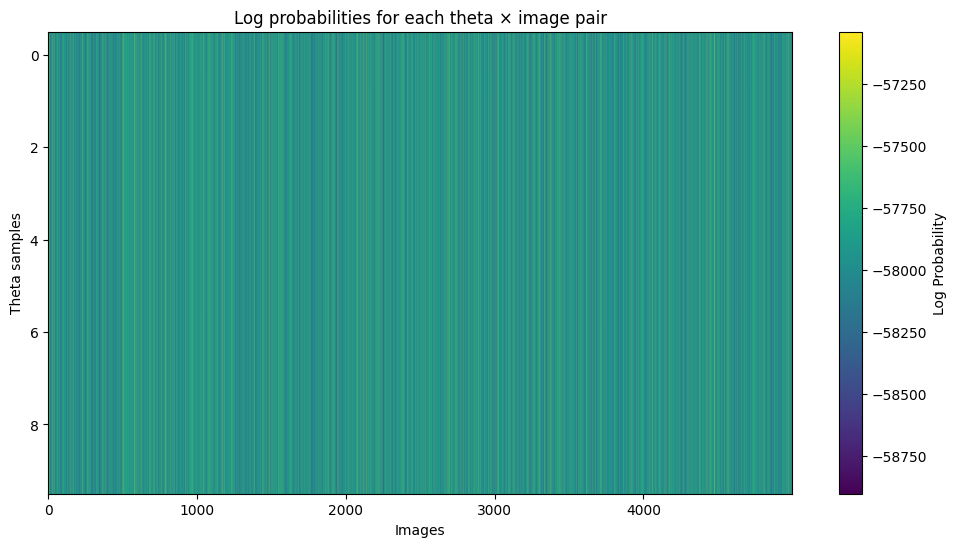

In [ ]:
plt.figure(figsize=(12, 6))
plt.imshow(log, aspect='auto', cmap='viridis')
#plt.imshow(log_probs[:, ::300].cpu().numpy(), aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta samples')
plt.title('Log probabilities for each theta × image pair')
plt.show()


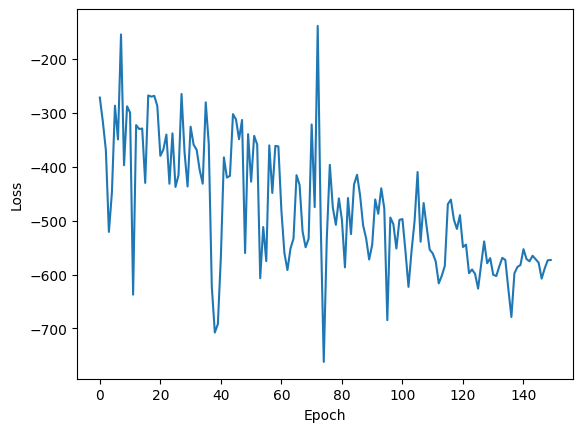

In [5]:
plt.plot(torch.load("tutorial.loss"))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [25]:
image_config = json.load(open(image_config))
image_prior = get_image_priors(len(models) - 1, image_config, device="cpu")
prior_loader = PriorLoader(
image_prior, batch_size=simulation_batch_size, num_workers=n_workers
    )

num_pixels = torch.tensor(
image_config["N_PIXELS"], dtype=torch.float32, device=device
)
pixel_size = torch.tensor(
image_config["PIXEL_SIZE"], dtype=torch.float32, device=device
)

In [ ]:
estimator.eval()
log_probs_list = []

for parameters in islice(prior_loader, 100):  # same as training
    indices, quaternions, res, shift, defocus, b_factor, amp, snr = parameters

    # Regenerate images on-the-fly
    images = cryo_em_simulator(
            models,
            indices.to("cpu"),  # keep CPU for indexing
            quaternions.to("cpu"),
            res.to("cpu"),
            shift.to("cpu"),
            defocus.to("cpu"),
            b_factor.to("cpu"),
            amp.to("cpu"),
            snr.to("cpu"),
            num_pixels,
            pixel_size
        )

    # Compute pairwise log-probs batch by batch
    for _indices, _images in zip(indices.split(BATCH_SIZE), images.split(BATCH_SIZE)):
        theta_batch = models[_indices.round().long().flatten().cpu()]
        theta_batch = theta_batch.transpose(1, 2).to(device)  # move to GPU
        flat_images = _images.view(_images.size(0), -1).to(device)

        with torch.no_grad():
            posterior = estimator.flow(theta_batch.to(device))
            log_probs_batch = posterior.log_prob(flat_images.to(device))

        log_probs_list.append(log_probs_batch.cpu())

# Concatenate all batches
log_probs_training_style = torch.cat(log_probs_list, dim=0)
print(log_probs_training_style.shape)


torch.Size([16000])


In [52]:
np.shape(log_probs_list)

(500, 32)

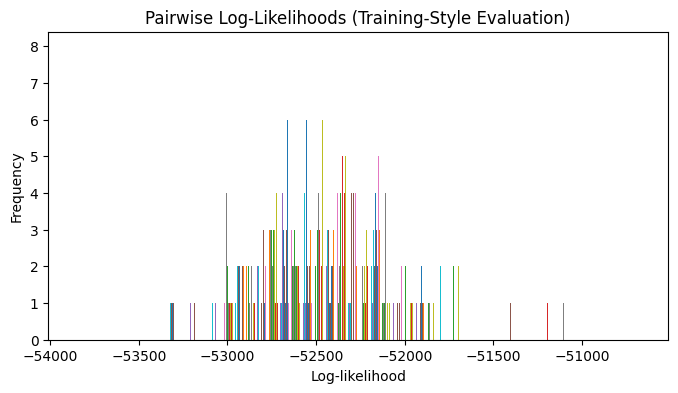

In [53]:
plt.figure(figsize=(8,4))
plt.hist(log_probs_list, bins=50)
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.title("Pairwise Log-Likelihoods (Training-Style Evaluation)")
plt.show()


In [9]:
np.shape(log_probs_list)

(500, 32)

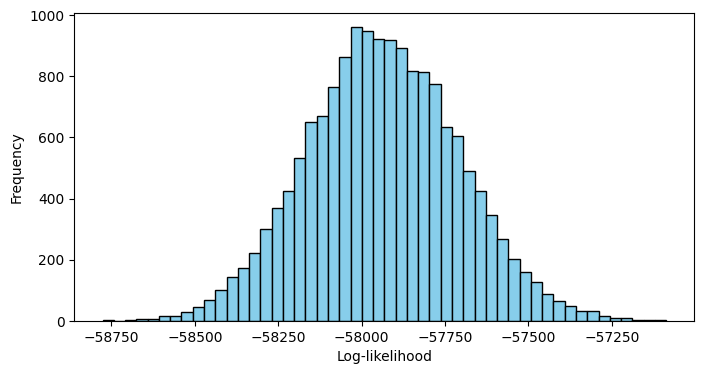

In [53]:
plt.figure(figsize=(8,4))
plt.hist(log_probs_training_style, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.show()


In [54]:
np.shape(log_probs_list)

(500, 32)

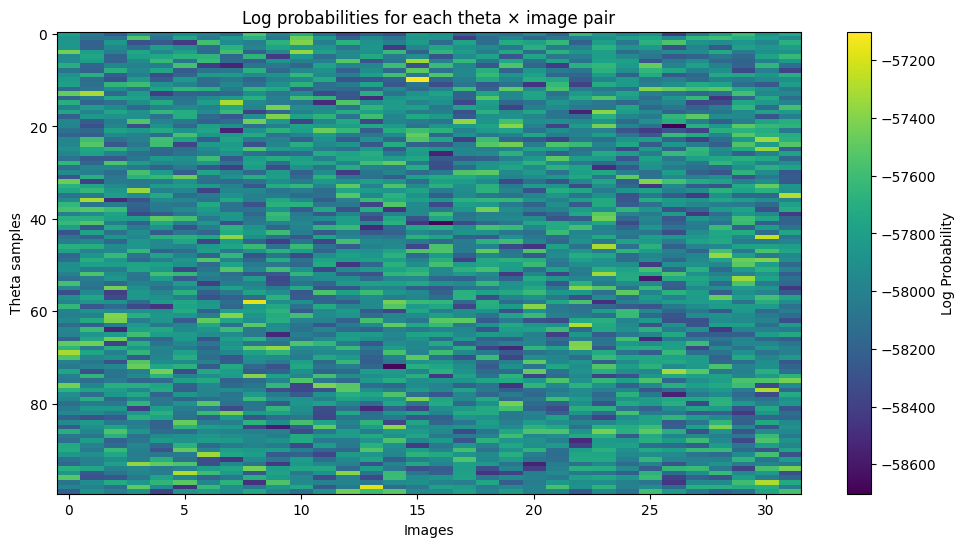

In [55]:


# log_probs: [num_thetas, num_images]
plt.figure(figsize=(12, 6))
plt.imshow(log_probs_list[:100], aspect='auto', cmap='viridis')
#plt.imshow(log_probs[:, ::300].cpu().numpy(), aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta samples')
plt.title('Log probabilities for each theta × image pair')
plt.show()


In [12]:
import torch

def evaluate_log_prob_cartesian(
    estimator: torch.nn.Module,
    images: torch.Tensor,     # [num_images, ...]
    theta: torch.Tensor,      # [num_thetas, ...]
    device: str = "cuda",
    batch_size_theta: int = 16,
    batch_size_images: int = 128
) -> torch.Tensor:
    """
    Computes Cartesian log-probabilities for all θ × all images.

    Args:
        estimator (torch.nn.Module): Flow model to evaluate.
        images (torch.Tensor): Images to condition on. Shape [num_images, ...].
        theta (torch.Tensor): Parameter values. Shape [num_thetas, ...].
        device (str): Device for computation ("cuda" or "cpu").
        batch_size_theta (int): Batch size for θ to avoid OOM.
        batch_size_images (int): Batch size for images to avoid OOM.

    Returns:
        torch.Tensor: [num_thetas, num_images] log-likelihoods.
    """
    num_images = images.shape[0]
    flat_images = images.view(num_images, -1)  # flatten images

    num_thetas = theta.shape[0]
    log_probs_all = []

    for theta_batch in theta.split(batch_size_theta, dim=0):
        batch_log_probs = []

        for img_batch in flat_images.split(batch_size_images, dim=0):
            # Expand θ to match image batch
            theta_exp = theta_batch[:, None, ...]  # [Bθ, 1, ...]
            theta_exp = theta_exp.expand(-1, img_batch.shape[0], *theta_batch.shape[1:])  # [Bθ, Bimg, ...]
            theta_broadcast = theta_exp.reshape(-1, *theta_batch.shape[1:])  # flatten to 2D if needed

            # Expand images to match θ batch
            images_exp = img_batch[None, :, :].expand(theta_batch.shape[0], -1, img_batch.shape[1]).reshape(-1, img_batch.shape[1])

            with torch.no_grad():
                posterior = estimator.flow(theta_broadcast.to(device))
                log_probs = posterior.log_prob(images_exp.to(device))

            # Reshape back to [Bθ, Bimg]
            log_probs = log_probs.view(theta_batch.shape[0], img_batch.shape[0])
            batch_log_probs.append(log_probs.cpu())

        # Concatenate image batches along axis=1
        batch_log_probs = torch.cat(batch_log_probs, dim=1)  # [Bθ, num_images]
        log_probs_all.append(batch_log_probs)

    # Concatenate theta batches along axis=0
    log_probs_all = torch.cat(log_probs_all, dim=0)  # [num_thetas, num_images]
    return log_probs_all


In [6]:
simulator = CryoEmSimulator(
    "simulation_parameters.json"
)  # creating simulator with simulation parameters

images, parameters = simulator.simulate(
    num_sim=5000, return_parameters=True
)  # simulating images and save parameters

side_length = parameters[0]  # extracting side_length from parameters
snr = parameters[-1]  # extracting snr from parameters

In [15]:
log_probs_cartesian = evaluate_log_prob_cartesian(
    estimator,
    images_eval,  # [num_images, H, W]
    models,   # [num_thetas, D]
    device="cuda",
    batch_size_theta=16,
    batch_size_images=64
)

print(log_probs_cartesian.shape)  # [num_thetas, num_images]


torch.Size([100, 5000])


In [16]:
log_probs = log_probs_cartesian.cpu().numpy() 

In [17]:
np.save('log_probs',log_probs)

In [56]:
np.save('log_probs_list',log_probs_list)


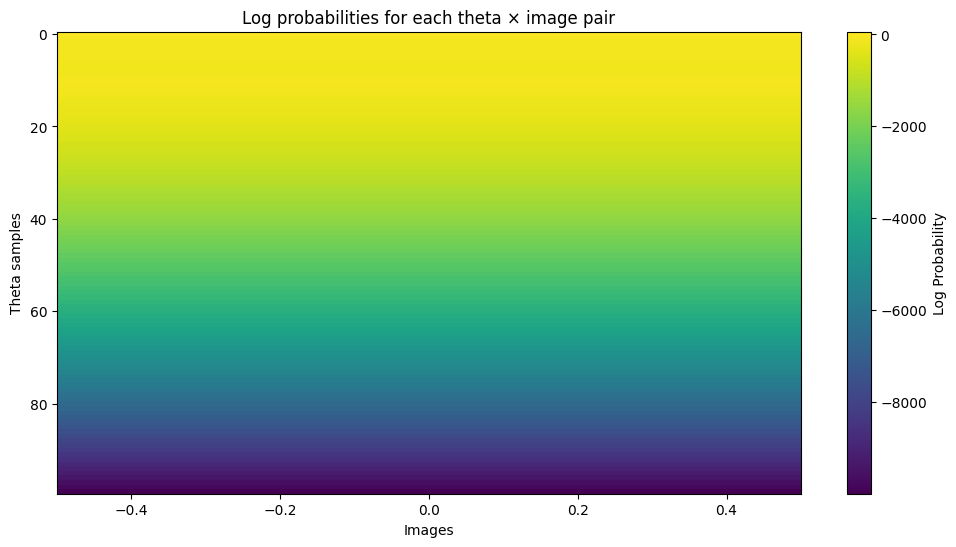

In [57]:


# log_probs: [num_thetas, num_images]
plt.figure(figsize=(12, 6))
plt.imshow(log_probs[:, ::300], aspect='auto', cmap='viridis')
#plt.imshow(log_probs[:, ::300].cpu().numpy(), aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta samples')
plt.title('Log probabilities for each theta × image pair')
plt.show()


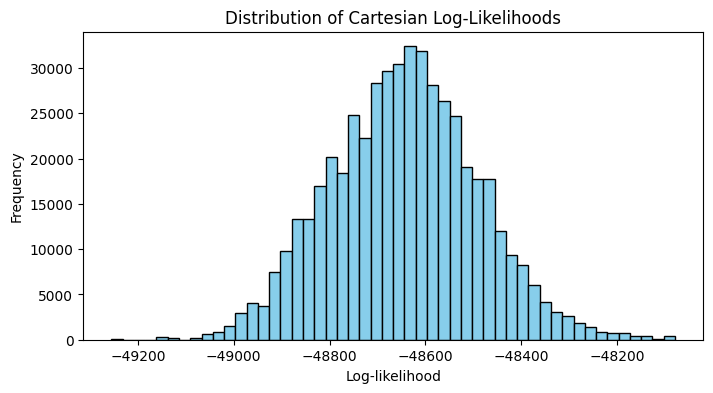

In [21]:
plt.figure(figsize=(8,4))
plt.hist(log_probs_cartesian.flatten().numpy(), bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.title("Distribution of Cartesian Log-Likelihoods")
plt.show()


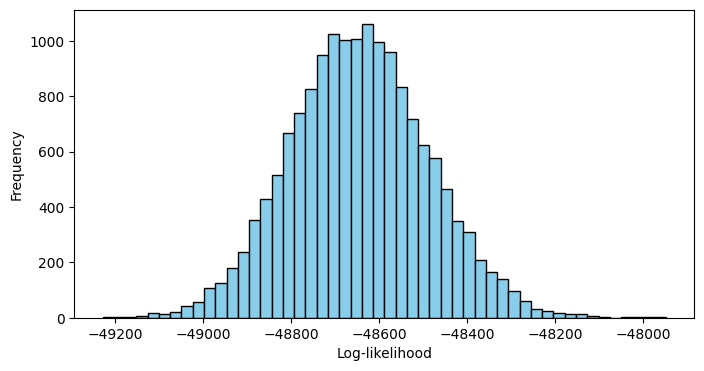

In [22]:
plt.figure(figsize=(8,4))
plt.hist(log_probs_training_style, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.show()


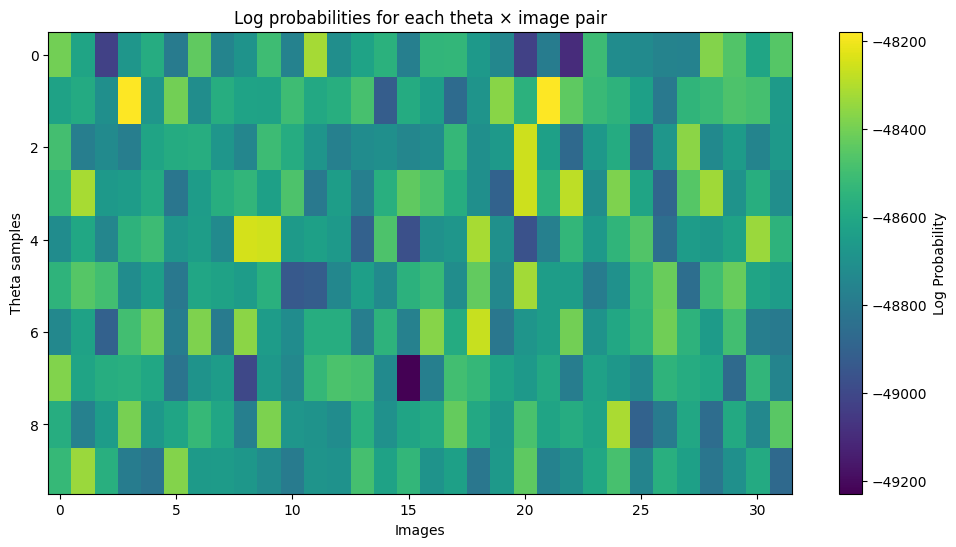

In [26]:


# log_probs: [num_thetas, num_images]
plt.figure(figsize=(12, 6))
plt.imshow(log_probs_list[:10], aspect='auto', cmap='viridis')
#plt.imshow(log_probs[:, ::300].cpu().numpy(), aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta samples')
plt.title('Log probabilities for each theta × image pair')
plt.show()


In [22]:
import torch

def evaluate_log_prob_cartesian(estimator, images, theta, device="cuda",
                                batch_size_theta=16, batch_size_images=32):
    estimator.eval()
    num_images = images.shape[0]
    num_theta = theta.shape[0]

    log_probs_all = torch.empty(num_theta, num_images)

    with torch.no_grad():
        img_start = 0
        for img_batch in images.split(batch_size_images, dim=0):
            Bimg = img_batch.shape[0]

            # posterior conditional on image batch
            posterior = estimator.nle.flow(estimator.embedding_2(img_batch.to(device)))

            theta_start = 0
            for theta_batch in theta.split(batch_size_theta, dim=0):
                Bθ = theta_batch.shape[0]

                # Expand theta for broadcast over images
                theta_exp = theta_batch[:, None, :, :].expand(-1, Bimg, -1, -1)
                theta_exp = theta_exp.reshape(-1, *theta_batch.shape[1:])

                logp = posterior.log_prob(theta_exp.to(device))  # [Bθ*Bimg]
                logp = logp.view(Bθ, Bimg)                        # [Bθ, Bimg]

                log_probs_all[theta_start:theta_start+Bθ, img_start:img_start+Bimg] = logp.cpu()
                theta_start += Bθ

            img_start += Bimg

    return log_probs_all


In [19]:
images.shape

torch.Size([160, 64, 64])

In [23]:
log_probs = evaluate_log_prob_cartesian(estimator, images, models)
print(log_probs)  # torch.Size([100, 160])
print(log_probs[:3, :5])  # first few values


RuntimeError: The size of tensor a (32) must match the size of tensor b (3) at non-singleton dimension 1

In [43]:
import torch

def evaluate_log_prob_cartesian(estimator, images, theta, device="cuda"):
    """
    Compute log p(theta | x) for all θ × all images.
    Returns [num_theta, num_images].
    """
    estimator.eval()
    num_images = images.shape[0]
    num_theta = theta.shape[0]

    # flatten theta for the flow
    theta_flat = theta.view(num_theta, -1)

    log_probs_all = torch.empty(num_theta, num_images)

    with torch.no_grad():
        for img_idx, image in enumerate(images):
            # posterior conditioned on single image
            posterior = estimator.nle.flow(estimator.embedding_2(image.unsqueeze(0).to(device)))
            # evaluate all θ under this posterior
            log_probs_all[:, img_idx] = posterior.log_prob(theta_flat.to(device)).cpu()

    return log_probs_all


In [44]:
log_probs = evaluate_log_prob_cartesian(estimator, images, models)
print(log_probs.shape)  # torch.Size([100, 160])
print(log_probs[:3, :5])  # first few values


torch.Size([100, 160])
tensor([[  58.2864,   58.3055,   58.3055,   58.3054,   58.2864],
        [ -96.8871,  -96.8806,  -96.8805,  -96.8803,  -96.8872],
        [-106.9944, -106.9879, -106.9877, -106.9878, -106.9944]])


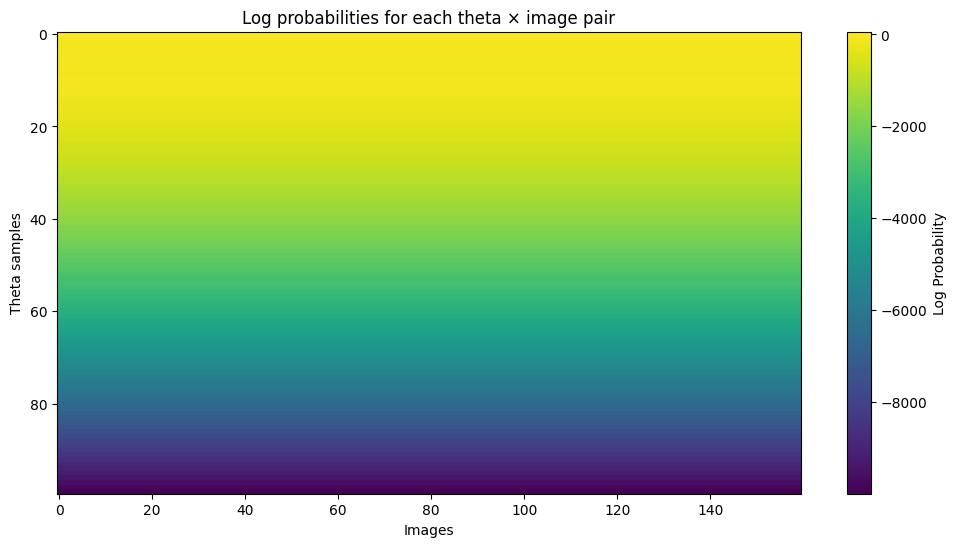

In [45]:


# log_probs: [num_thetas, num_images]
plt.figure(figsize=(12, 6))
plt.imshow(log_probs, aspect='auto', cmap='viridis')
#plt.imshow(log_probs[:, ::300].cpu().numpy(), aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta samples')
plt.title('Log probabilities for each theta × image pair')
plt.show()


In [46]:
print(log_probs)

tensor([[   58.2864,    58.3055,    58.3055,  ...,    58.2890,    58.2864,
            58.2889],
        [  -96.8871,   -96.8806,   -96.8805,  ...,   -96.8864,   -96.8871,
           -96.8860],
        [ -106.9944,  -106.9879,  -106.9877,  ...,  -106.9940,  -106.9947,
          -106.9936],
        ...,
        [-9587.9639, -9587.9570, -9587.9570,  ..., -9587.9629, -9587.9639,
         -9587.9629],
        [-9786.9229, -9786.9160, -9786.9160,  ..., -9786.9219, -9786.9229,
         -9786.9219],
        [-9987.9229, -9987.9160, -9987.9160,  ..., -9987.9219, -9987.9229,
         -9987.9219]])


In [47]:
np.save('log_probs',log_probs)

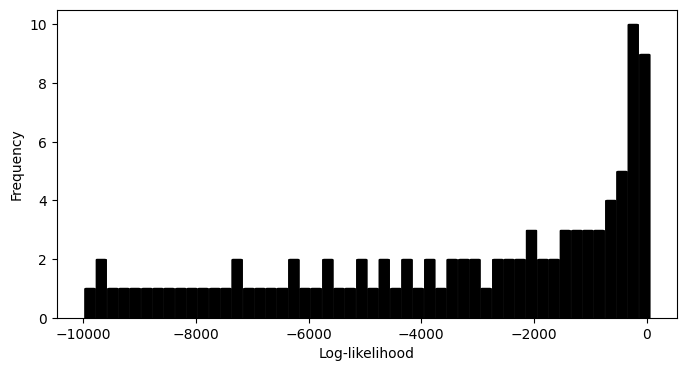

In [48]:
plt.figure(figsize=(8,4))
plt.hist(log_probs, bins=50, edgecolor='black')
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.show()


In [49]:
print(log_probs.max(dim=1))
print(log_probs.min(dim=1))


torch.return_types.max(
values=tensor([   58.3118,   -96.8789,  -106.9864,   -99.9083,  -101.1812,  -107.1550,
         -174.8557,  -172.6675,  -171.8766,  -165.5339,   -89.9446,  -111.3710,
         -134.8380,  -160.3456,  -187.8938,  -217.4826,  -249.1121,  -282.7821,
         -318.4927,  -356.2439,  -396.0358,  -437.8683,  -481.7414,  -527.6551,
         -575.6094,  -625.6042,  -677.6397,  -731.7158,  -787.8326,  -845.9899,
         -906.1877,  -968.4263, -1032.7056, -1099.0254, -1167.3857, -1237.7867,
        -1310.2283, -1384.7106, -1461.2330, -1539.7965, -1620.4005, -1703.0452,
        -1787.7305, -1874.4563, -1963.2228, -2054.0298, -2146.8777, -2241.7659,
        -2338.6948, -2437.6638, -2538.6748, -2641.7251, -2746.8167, -2853.9485,
        -2963.1211, -3074.3342, -3187.5881, -3302.8823, -3420.2175, -3539.5930,
        -3661.0093, -3784.4661, -3909.9631, -4037.5012, -4167.0806, -4298.6997,
        -4432.3599, -4568.0601, -4705.8003, -4845.5815, -4987.4038, -5131.2671,
        -

In [8]:
models.shape

torch.Size([100, 3, 4])

In [10]:
import torch
import matplotlib.pyplot as plt

# Assume:
# - estimator: your trained NLEWithEmbedding
# - images: torch.Tensor of shape [num_samples, H, W]
# - models: torch.Tensor of shape [num_samples, theta_dim1, theta_dim2] (the θ corresponding to each image)
# - device: "cuda" or "cpu"

def evaluate_pairwise_log_prob(estimator, images, theta, device="cuda"):
    """
    Computes pairwise log-likelihoods: each θ[i] with image[i].
    """
    num_samples = images.shape[0]
    
    # Flatten images like during training
    flat_images = images.view(num_samples, -1)
    
    with torch.no_grad():
        log_probs = estimator.forward(flat_images.to(device), theta.to(device))
    
    return log_probs.cpu()  # [num_samples]


# Compute pairwise log-likelihoods
log_probs_pairwise = evaluate_pairwise_log_prob(estimator, images, models, device="cuda")

# Basic visualization
plt.figure(figsize=(8,4))
plt.hist(log_probs_pairwise.numpy(), bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.title("Pairwise Log-Likelihoods on Training Data")
plt.show()

# Optional: summary statistics
print("Mean log-likelihood:", log_probs_pairwise.mean().item())
print("Std log-likelihood:", log_probs_pairwise.std().item())
print("Min / Max log-likelihood:", log_probs_pairwise.min().item(), "/", log_probs_pairwise.max().item())


RuntimeError: Attempting to broadcast a dimension of length 100 at -1! Mismatching argument at index 1 had torch.Size([100]); but expected shape should be broadcastable to [5000]

In [9]:
import torch

def evaluate_pairwise_log_prob(estimator, images, theta, device="cuda"):
    """
    Compute log p(x_i | theta_i) for the training data.

    Args:
        estimator: your trained NLEWithEmbedding
        images: [num_samples, H, W] or flattened
        theta: [num_samples, dim1, dim2] or as used in training
        device: "cuda" or "cpu"

    Returns:
        log_probs: [num_samples] log-likelihoods
    """
    estimator.eval()
    num_samples = images.shape[0]

    # flatten images like training
    flat_images = images.view(num_samples, -1)

    log_probs = []

    with torch.no_grad():
        for i in range(num_samples):
            # get posterior conditioned on theta_i
            posterior = estimator.flow(theta[i].unsqueeze(0).to(device))
            # evaluate the log-prob of x_i
            logp = posterior.log_prob(flat_images[i].unsqueeze(0).to(device))
            log_probs.append(logp.cpu())

    return torch.cat(log_probs, dim=0)


In [ ]:
estimator

In [10]:
log_probs_training = evaluate_pairwise_log_prob(estimator, images, models, device="cuda")

print("Shape:", log_probs_training.shape)  # should be [num_samples]
print("Mean log-likelihood:", log_probs_training.mean().item())
print("Std log-likelihood:", log_probs_training.std().item())

# Optional: histogram
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(log_probs_training.numpy(), bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.title("Pairwise Log-Likelihoods on Training Data")
plt.show()


IndexError: index 100 is out of bounds for dimension 0 with size 100

In [15]:
image_config = json.load(open(image_config))
image_prior = get_image_priors(len(models) - 1, image_config, device="cpu")
prior_loader = PriorLoader(
image_prior, batch_size=simulation_batch_size, num_workers=n_workers
    )

num_pixels = torch.tensor(
image_config["N_PIXELS"], dtype=torch.float32, device=device
)
pixel_size = torch.tensor(
image_config["PIXEL_SIZE"], dtype=torch.float32, device=device
)

In [16]:
log_probs_list = []

estimator.eval()
with torch.no_grad():
    for parameters in islice(prior_loader, 100):
        indices, quaternions, res, shift, defocus, b_factor, amp, snr = parameters
        
        # Generate images on-the-fly
        images = cryo_em_simulator(
            models,
            indices.to("cpu"),  # CPU is fine for indexing
            quaternions.to("cpu"),
            res.to("cpu"),
            shift.to("cpu"),
            defocus.to("cpu"),
            b_factor.to("cpu"),
            amp.to("cpu"),
            snr.to("cpu"),
            num_pixels,
            pixel_size
        )
        
        for _indices, _images in zip(indices.split(BATCH_SIZE), images.split(BATCH_SIZE)):
            theta_batch = models[_indices.round().long().flatten()].transpose(1,2).to(device)
            flat_images = _images.view(_images.size(0), -1).to(device)

            posterior = estimator.flow(theta_batch)  # θ-conditioned posterior
            log_probs_batch = posterior.log_prob(flat_images)

            log_probs_list.append(log_probs_batch.cpu())

log_probs_training_style = torch.cat(log_probs_list, dim=0)


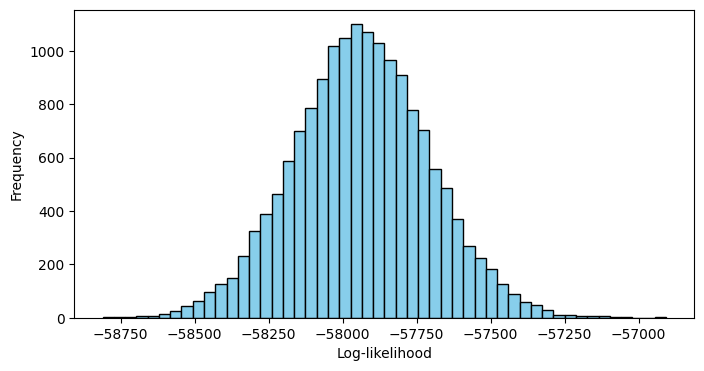

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(log_probs_training_style, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.show()


In [19]:
np.shape(log_probs_list)

(500, 32)

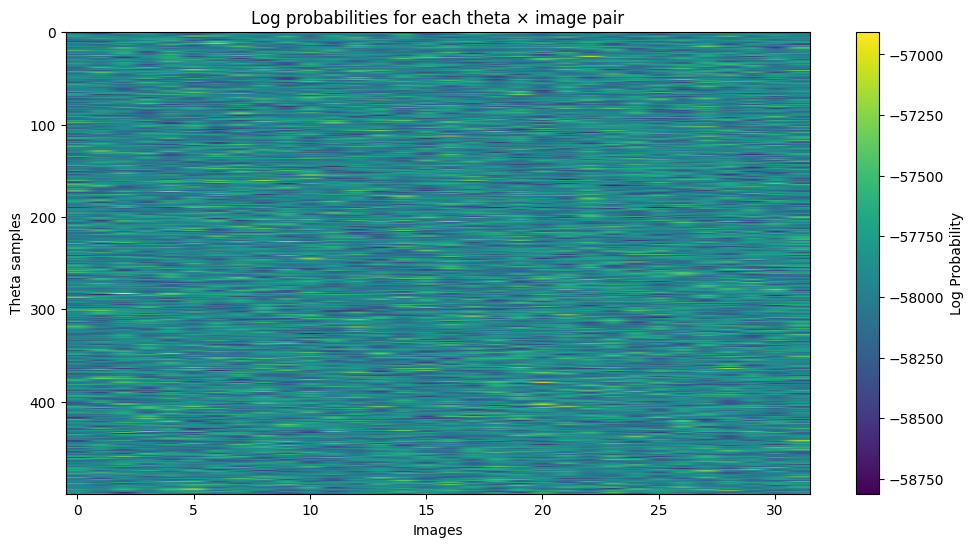

In [20]:
plt.figure(figsize=(12, 6))
plt.imshow(log_probs_list, aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta samples')
plt.title('Log probabilities for each theta × image pair')
plt.show()
